# Fusión Temporal + Espectral para Detección de Parkinson
## Embeddings temporales (Wav2Vec2/HuBERT) + Features espectrales (Mel-Espectrograma + ResNet18)

**Hipótesis**: La vocal sostenida /a/ contiene información discriminativa en dos dominios complementarios:
1. **Temporal**: Irregularidades ciclo a ciclo (jitter, shimmer) → Wav2Vec2, HuBERT
2. **Espectral**: Estructura armónica, HNR, formantes → mel-espectrograma + CNN ImageNet

**Resultado previo (techo temporal)**: BASE+HuBERT = AUC 0.856 ± 0.086

**Motivación SOTA**:
- Wodzinski et al. (2019): ResNet + espectrograma, PC-GITA (100 sujetos) → acc >90%
- Madusanka & Lee (2024): AST → 91.67% en PC-GITA
- Klempíř et al. (2023): proponen combinar wav2vec con representaciones espectrales

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

%load_ext autoreload
%autoreload 2

# -------------------------------------------------------
# Constantes globales
# -------------------------------------------------------
TARGET_SR = 16_000
RANDOM_STATE = 42
N_FOLDS = 5
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: mps
PyTorch: 2.10.0


## 1. Carga y Preprocesamiento

Pipeline idéntico al notebook de raw waves para garantizar comparabilidad.

In [2]:
from src.preprocessing import load_metadata, load_waveforms, preprocess_waveform

df_metadata = load_metadata(base_path="data")
waveforms_raw, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)
waveforms_processed = [preprocess_waveform(wf) for wf in waveforms_raw]

durations_processed = [len(wf) / TARGET_SR for wf in waveforms_processed]
print(f"\nSujetos: {len(waveforms_processed)}")
print(f"Duración media: {np.mean(durations_processed):.2f}s")
print(f"Duración mediana: {np.median(durations_processed):.2f}s")


Sujetos: 100
Duración media: 4.31s
Duración mediana: 4.03s


## 2. Representación Espectral: Mel-Espectrograma

### Fundamento matemático

La **STFT** descompone la señal en componentes frecuenciales locales:

$$X(k, t) = \sum_{n=0}^{N-1} x[n + t \cdot H] \cdot w[n] \cdot e^{-j2\pi kn/N}$$

El **banco de filtros mel** aplica una escala perceptual humana:

$$f_{\text{mel}} = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

La conversión a **decibelios** comprime el rango dinámico:

$$S_{\text{dB}}(m, t) = 10 \cdot \log_{10}\left(\sum_k |X(k,t)|^2 \cdot H_m(k) + \varepsilon\right)$$

### ¿Por qué funciona para Parkinson?

En pacientes PD, la vocal sostenida muestra:
- **Armónicos más débiles y difusos** → menor energía en bandas armónicas
- **Mayor ruido interarmónico** → bajo HNR
- **Inestabilidad formántica** → variaciones en frecuencias formánticas
- **Voz hipofónica** → concentración de energía en bajas frecuencias

Todo esto es visible como patrones 2D en el mel-espectrograma.

In [3]:
from src.spectral import generate_mel_spectrograms

MEL_CONFIG = {
    "sample_rate": TARGET_SR,
    "n_fft": 1024,        # Resolución frecuencial: Δf ≈ 15.6 Hz
    "hop_length": 512,    # 50% overlap entre ventanas STFT
    "n_mels": 128,        # 128 bandas mel
}

mel_spectrograms = generate_mel_spectrograms(waveforms_processed, **MEL_CONFIG)

print(f"\nMel-espectrogramas generados: {len(mel_spectrograms)}")
print(f"Shape ejemplo [0]: {mel_spectrograms[0].shape}  (n_mels × frames)")
print(f"Shape ejemplo [50]: {mel_spectrograms[50].shape}")
print(f"Rango dB: [{mel_spectrograms[0].min():.1f}, {mel_spectrograms[0].max():.1f}]")


Mel-espectrogramas generados: 100
Shape ejemplo [0]: (128, 107)  (n_mels × frames)
Shape ejemplo [50]: (128, 121)
Rango dB: [-45.9, 34.1]


### Visualización: PD vs HD en ambos dominios

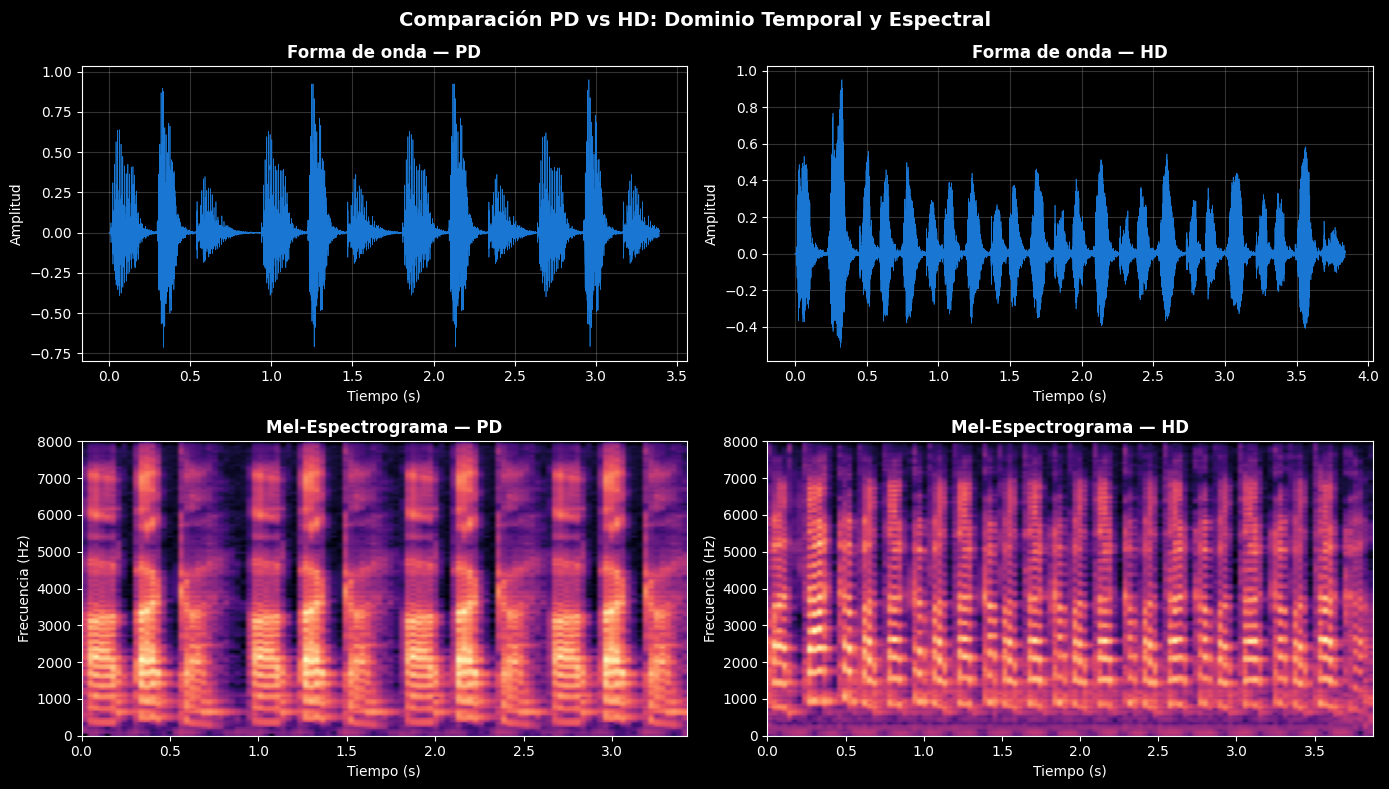

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

pd_indices = df_metadata.with_row_index().filter(pl.col("label") == 1)["index"].to_list()
hd_indices = df_metadata.with_row_index().filter(pl.col("label") == 0)["index"].to_list()

for col, (idx, label) in enumerate([(pd_indices[0], "PD"), (hd_indices[0], "HD")]):
    t = np.arange(len(waveforms_processed[idx])) / TARGET_SR
    axes[0, col].plot(t, waveforms_processed[idx], linewidth=0.5, color="#1976D2")
    axes[0, col].set_title(f"Forma de onda — {label}", fontweight="bold")
    axes[0, col].set_xlabel("Tiempo (s)")
    axes[0, col].set_ylabel("Amplitud")
    axes[0, col].grid(True, alpha=0.2)

    mel = mel_spectrograms[idx]
    hop = MEL_CONFIG["hop_length"]
    axes[1, col].imshow(
        mel, aspect="auto", origin="lower",
        extent=[0, mel.shape[1] * hop / TARGET_SR, 0, TARGET_SR / 2],
        cmap="magma",
    )
    axes[1, col].set_title(f"Mel-Espectrograma — {label}", fontweight="bold")
    axes[1, col].set_xlabel("Tiempo (s)")
    axes[1, col].set_ylabel("Frecuencia (Hz)")

plt.suptitle("Comparación PD vs HD: Dominio Temporal y Espectral",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Transfer Learning: ResNet18 sobre Mel-Espectrogramas

### ¿Por qué transfer learning desde ImageNet?

Un mel-espectrograma es una imagen 2D. Los modelos preentrenados en ImageNet ya saben detectar bordes, texturas y patrones repetitivos — exactamente las features relevantes en un espectrograma (líneas armónicas, bandas de ruido, estructura formántica).

### Pipeline de extracción
```
Señal x(t) → Mel-Espectrograma (128 × T)
           → Normalización [0, 1]
           → Resize bilineal a (224 × 224)
           → Replicar a 3 canales (pseudo-RGB)
           → Normalización ImageNet (μ, σ)
           → ResNet18 congelado (sin FC)
           → Average Pooling global
           → Vector de 512 dimensiones
```

### ¿Por qué ResNet18?

Con 100 muestras y un extractor congelado (no se entrena), ResNet18 (11.7M params, 512-dim output) tiene el balance correcto. Modelos más grandes (ResNet50: 2048-dim) generarían features redundantes.

In [5]:
from src.spectral import extract_spectral_features

spectral_features = extract_spectral_features(
    waveforms_processed,
    device=DEVICE,
    **MEL_CONFIG,
)

print(f"\nFeatures espectrales finales: {spectral_features.shape}")  # (100, 512)

Generando mel-espectrogramas...
  100 espectrogramas generados
  Shape ejemplo: (128, 107)
Extrayendo features con ResNet18 (ImageNet)...
  25/100
  50/100
  75/100
  100/100
  Features espectrales: (100, 512)

Features espectrales finales: (100, 512)


## 4. Embeddings Temporales (Baseline)

Embeddings congelados de Wav2Vec2-BASE + HuBERT-BASE — la mejor fusión temporal (AUC=0.856).

In [6]:
from src.embeddings import extract_embeddings

all_indices = np.arange(len(waveforms_processed))

print("Extrayendo embeddings temporales...")
emb_base, labels = extract_embeddings(
    df_metadata, waveforms_processed, all_indices, "facebook/wav2vec2-base", DEVICE
)
emb_hubert, _ = extract_embeddings(
    df_metadata, waveforms_processed, all_indices, "facebook/hubert-base-ls960", DEVICE
)

emb_temporal = np.concatenate([emb_base, emb_hubert], axis=1)

print(f"\nWav2Vec2-BASE: {emb_base.shape}")
print(f"HuBERT-BASE:   {emb_hubert.shape}")
print(f"Temporal (concat): {emb_temporal.shape}")  # (100, 1536)

Extrayendo embeddings temporales...
  Cargando facebook/wav2vec2-base...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2678.78it/s, Materializing param=masked_spec_embed]                                            
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Cargando facebook/hubert-base-ls960...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2317.89it/s, Materializing param=masked_spec_embed]                                            



Wav2Vec2-BASE: (100, 768)
HuBERT-BASE:   (100, 768)
Temporal (concat): (100, 1536)


## 5. Diseño Experimental

Fusión por **concatenación tardía (late fusion)**:

$$\mathbf{z}_{\text{fusion}} = [\mathbf{z}_{\text{temporal}} \| \mathbf{z}_{\text{espectral}}] \in \mathbb{R}^{2048}$$

| Exp | Representación | Dim | Origen |
|-----|---------------|-----|--------|
| A | Temporal (BASE+HuBERT) | 1536 | Embeddings congelados |
| B | Espectral (ResNet18-Mel) | 512 | Transfer learning ImageNet |
| C | Fusión (A ∥ B) | 2048 | Concatenación |

In [7]:
FUSION_EXPERIMENTS = {
    "A: Temporal (BASE+HuBERT)":     emb_temporal,
    "B: Espectral (ResNet18-Mel)":   spectral_features,
    "C: Fusión Temporal+Espectral":  np.concatenate(
        [emb_temporal, spectral_features], axis=1
    ),
}

for name, emb in FUSION_EXPERIMENTS.items():
    print(f"  {name}: {emb.shape}")

  A: Temporal (BASE+HuBERT): (100, 1536)
  B: Espectral (ResNet18-Mel): (100, 512)
  C: Fusión Temporal+Espectral: (100, 2048)


## 6. Evaluación: 5-Fold CV + Grid Search (PCA + SVM)

Mismo pipeline que los experimentos anteriores:
- **PCA**: [3, 5, 10, 20, 50, 100] componentes
- **SVM C**: [0.01, 0.1, 1.0, 10.0]
- **Kernel**: [rbf, linear]
- **Umbral de Youden**: $J = \text{Sens} + \text{Spec} - 1$

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve
import itertools

PCA_COMPONENTS = [3, 5, 10, 20, 50]
SVM_C = [0.01, 0.1, 1.0, 10.0]
SVM_KERNELS = ["rbf", "linear"]

labels_arr = np.array(labels)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results = {}

for exp_name, embeddings in FUSION_EXPERIMENTS.items():
    print(f"\n{'='*65}")
    print(f"  {exp_name} — shape: {embeddings.shape}")
    print(f"{'='*65}")

    best_auc_mean = -1
    best_combo = None

    for n_pca, C, kernel in itertools.product(PCA_COMPONENTS, SVM_C, SVM_KERNELS):
        if n_pca >= embeddings.shape[1]:
            continue

        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(embeddings, labels_arr):
            X_train = embeddings[train_idx]
            X_test  = embeddings[test_idx]
            y_train = labels_arr[train_idx]
            y_test  = labels_arr[test_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

            pca = PCA(n_components=n_pca)
            X_train = pca.fit_transform(X_train)
            X_test  = pca.transform(X_test)

            svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm.fit(X_train, y_train)

            y_prob = svm.predict_proba(X_test)[:, 1]

            fpr, tpr, thresholds = roc_curve(y_test, y_prob)
            j_scores = tpr - fpr
            best_thr = thresholds[np.argmax(j_scores)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_test, y_prob))
            fold_accs.append(accuracy_score(y_test, y_pred))
            fold_sens.append(recall_score(y_test, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_test, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)

        if mean_auc > 0.80:
            print(f"  PCA={n_pca:<4} C={C:<5} kernel={kernel:<7} → AUC={mean_auc:.3f}")

        if mean_auc > best_auc_mean:
            best_auc_mean = mean_auc
            best_combo = {
                "pca": n_pca, "C": C, "kernel": kernel,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
                "fold_aucs": fold_aucs,
            }

    results[exp_name] = best_combo
    print(f"\n  ✅ Mejor: PCA={best_combo['pca']} C={best_combo['C']} kernel={best_combo['kernel']}")
    print(f"     AUC:  {best_combo['auc_mean']:.3f} ± {best_combo['auc_std']:.3f}")
    print(f"     Acc:  {best_combo['acc_mean']:.3f} ± {best_combo['acc_std']:.3f}")
    print(f"     Sens: {best_combo['sens_mean']:.3f} ± {best_combo['sens_std']:.3f}")
    print(f"     Spec: {best_combo['spec_mean']:.3f} ± {best_combo['spec_std']:.3f}")


  A: Temporal (BASE+HuBERT) — shape: (100, 1536)
  PCA=3    C=0.01  kernel=linear  → AUC=0.816
  PCA=3    C=0.1   kernel=linear  → AUC=0.818
  PCA=3    C=1.0   kernel=rbf     → AUC=0.812
  PCA=3    C=1.0   kernel=linear  → AUC=0.818
  PCA=3    C=10.0  kernel=linear  → AUC=0.818
  PCA=5    C=0.01  kernel=linear  → AUC=0.830
  PCA=5    C=0.1   kernel=linear  → AUC=0.828
  PCA=5    C=1.0   kernel=rbf     → AUC=0.816
  PCA=5    C=1.0   kernel=linear  → AUC=0.832
  PCA=5    C=10.0  kernel=linear  → AUC=0.832
  PCA=10   C=0.01  kernel=linear  → AUC=0.820
  PCA=10   C=0.1   kernel=linear  → AUC=0.829
  PCA=10   C=1.0   kernel=rbf     → AUC=0.838
  PCA=10   C=1.0   kernel=linear  → AUC=0.826
  PCA=10   C=10.0  kernel=rbf     → AUC=0.816
  PCA=10   C=10.0  kernel=linear  → AUC=0.826
  PCA=20   C=0.01  kernel=linear  → AUC=0.840
  PCA=20   C=0.1   kernel=linear  → AUC=0.848
  PCA=20   C=1.0   kernel=rbf     → AUC=0.858
  PCA=20   C=1.0   kernel=linear  → AUC=0.842
  PCA=20   C=10.0  kernel=rbf 

## 7. Tabla Comparativa

In [12]:
print(f"\n{'='*80}")
print(f"  RESULTADOS: FUSIÓN TEMPORAL + ESPECTRAL")
print(f"{'='*80}")
print(f"  {'Experimento':<40} {'AUC':>14} {'Acc':>14} {'Sens':>14} {'Spec':>14}")
print(f"  {'-'*40} {'-'*14} {'-'*14} {'-'*14} {'-'*14}")

for name, r in results.items():
    print(f"  {name:<40} "
          f"{r['auc_mean']:.3f}±{r['auc_std']:.3f}  "
          f"{r['acc_mean']:.3f}±{r['acc_std']:.3f}  "
          f"{r['sens_mean']:.3f}±{r['sens_std']:.3f}  "
          f"{r['spec_mean']:.3f}±{r['spec_std']:.3f}")

print(f"\n  {'Referencia':<40} {'AUC':>14}")
print(f"  {'-'*40} {'-'*14}")
print(f"  {'BASE+HuBERT (anterior, sin espectral)':<40} {'0.856±0.086':>14}")


  RESULTADOS: FUSIÓN TEMPORAL + ESPECTRAL
  Experimento                                         AUC            Acc           Sens           Spec
  ---------------------------------------- -------------- -------------- -------------- --------------
  A: Temporal (BASE+HuBERT)                0.854±0.091  0.870±0.081  0.840±0.136  0.900±0.063
  B: Espectral (ResNet18-Mel)              0.798±0.090  0.780±0.075  0.760±0.102  0.800±0.179
  C: Fusión Temporal+Espectral             0.872±0.065  0.840±0.058  0.740±0.102  0.940±0.049

  Referencia                                          AUC
  ---------------------------------------- --------------
  BASE+HuBERT (anterior, sin espectral)       0.856±0.086


## 8. Visualización

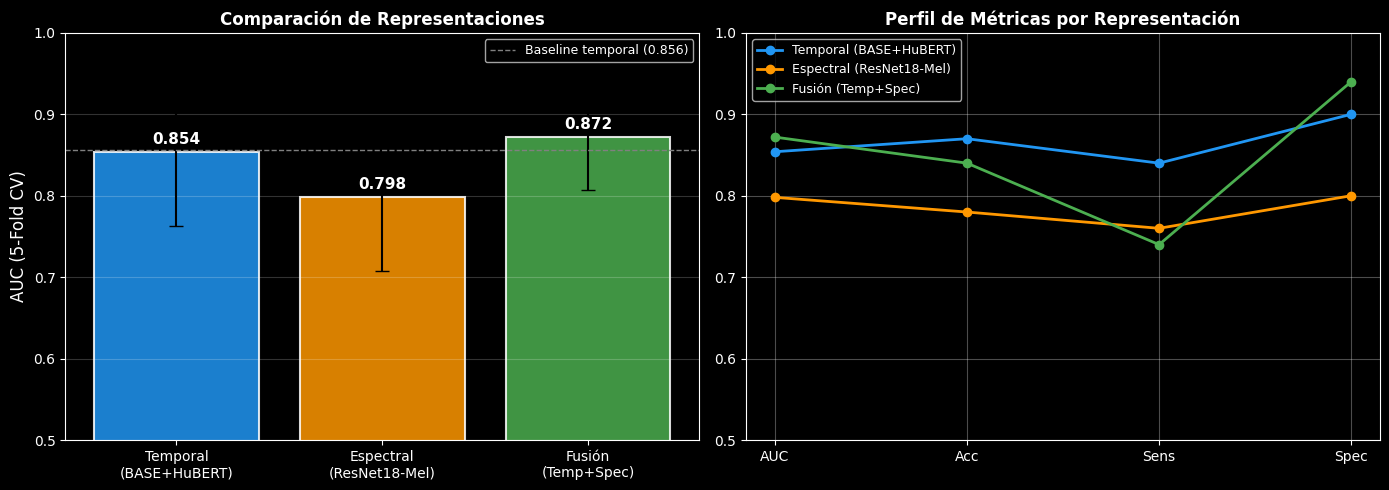

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
short_names = ["Temporal\n(BASE+HuBERT)", "Espectral\n(ResNet18-Mel)", "Fusión\n(Temp+Spec)"]
aucs = [results[n]["auc_mean"] for n in names]
auc_stds = [results[n]["auc_std"] for n in names]
colors = ["#2196F3", "#FF9800", "#4CAF50"]

bars = axes[0].bar(short_names, aucs, yerr=auc_stds, color=colors,
                   edgecolor="white", linewidth=1.5, capsize=5, alpha=0.85)
axes[0].axhline(0.856, color="gray", linestyle="--", linewidth=1,
                label="Baseline temporal (0.856)")
axes[0].set_ylabel("AUC (5-Fold CV)", fontsize=12)
axes[0].set_title("Comparación de Representaciones", fontweight="bold")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2, axis="y")

for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontweight="bold", fontsize=11)

metrics_names = ["AUC", "Acc", "Sens", "Spec"]
for i, name in enumerate(names):
    r = results[name]
    vals = [r["auc_mean"], r["acc_mean"], r["sens_mean"], r["spec_mean"]]
    axes[1].plot(metrics_names, vals, marker="o", linewidth=2, color=colors[i],
                 label=short_names[i].replace("\n", " "))

axes[1].set_ylim(0.5, 1.0)
axes[1].set_title("Perfil de Métricas por Representación", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Mejoras para superar 90% Accuracy

### Estrategias:
1. **Normalización independiente antes de concatenar**: igualar la escala de ambos dominios
2. **Fusión ponderada**: dar pesos diferentes a temporal vs espectral
3. **Más backbones espectrales**: probar EfficientNet, DenseNet además de ResNet18
4. **Ensemble a nivel de decisión**: en vez de concatenar features, promediar probabilidades

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve
import itertools

# ============================================================
# ESTRATEGIA 1: Normalización independiente por dominio
# ============================================================
# El problema de concatenar directamente es que los 1536 features
# temporales tienen una distribución diferente a los 512 espectrales.
# Si normalizamos CADA dominio por separado antes de concatenar,
# ambos contribuyen equitativamente al PCA.

scaler_temp = StandardScaler()
scaler_spec = StandardScaler()

emb_temp_normed = scaler_temp.fit_transform(emb_temporal)
emb_spec_normed = scaler_spec.fit_transform(spectral_features)

# ============================================================
# ESTRATEGIA 2: Fusión ponderada
# ============================================================
# Escalar el dominio espectral para darle más o menos peso.
# weight > 1 amplifica la contribución espectral.

WEIGHTS_SPECTRAL = [0.5, 1.0, 1.5, 2.0, 3.0]

# ============================================================
# ESTRATEGIA 4: Ensemble a nivel de decisión
# ============================================================
# En vez de concatenar features, entrenar SVMs separados y
# promediar probabilidades. Esto evita que el PCA mezcle
# los dominios de forma subóptima.

# -------------------------------------------------------
# Configuraciones a evaluar
# -------------------------------------------------------
ADVANCED_EXPERIMENTS = {}

# 2a. Fusión normalizada (sin ponderación)
ADVANCED_EXPERIMENTS["Fusión normalizada (1:1)"] = {
    "type": "concat",
    "data": np.concatenate([emb_temp_normed, emb_spec_normed], axis=1),
}

# 2b. Fusión ponderada (más peso espectral)
for w in WEIGHTS_SPECTRAL:
    ADVANCED_EXPERIMENTS[f"Fusión ponderada (spec×{w})"] = {
        "type": "concat",
        "data": np.concatenate([emb_temp_normed, emb_spec_normed * w], axis=1),
    }

# 4. Ensemble a nivel de decisión (se maneja aparte)
ADVANCED_EXPERIMENTS["Ensemble decisión (temp+spec)"] = {
    "type": "ensemble",
    "data_temp": emb_temporal,
    "data_spec": spectral_features,
}

# -------------------------------------------------------
# Evaluación
# -------------------------------------------------------
PCA_COMPONENTS = [3, 5, 10, 20, 50]
SVM_C = [0.01, 0.1, 1.0, 10.0]
SVM_KERNELS = ["rbf", "linear"]

labels_arr = np.array(labels)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results_advanced = {}

for exp_name, config in ADVANCED_EXPERIMENTS.items():
    print(f"\n{'='*65}")
    print(f"  {exp_name}")
    print(f"{'='*65}")

    best_auc_mean = -1
    best_combo = None

    if config["type"] == "concat":
        embeddings = config["data"]
        print(f"  Shape: {embeddings.shape}")

        for n_pca, C, kernel in itertools.product(PCA_COMPONENTS, SVM_C, SVM_KERNELS):
            if n_pca >= min(embeddings.shape[0], embeddings.shape[1]):
                continue

            fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

            for train_idx, test_idx in skf.split(embeddings, labels_arr):
                X_tr, X_te = embeddings[train_idx], embeddings[test_idx]
                y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

                sc = StandardScaler()
                X_tr = sc.fit_transform(X_tr)
                X_te = sc.transform(X_te)

                pca = PCA(n_components=n_pca)
                X_tr = pca.fit_transform(X_tr)
                X_te = pca.transform(X_te)

                svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
                svm.fit(X_tr, y_tr)
                y_prob = svm.predict_proba(X_te)[:, 1]

                fpr, tpr, thresholds = roc_curve(y_te, y_prob)
                best_thr = thresholds[np.argmax(tpr - fpr)]
                y_pred = (y_prob >= best_thr).astype(int)

                fold_aucs.append(roc_auc_score(y_te, y_prob))
                fold_accs.append(accuracy_score(y_te, y_pred))
                fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
                fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

            mean_auc = np.mean(fold_aucs)
            mean_acc = np.mean(fold_accs)

            if mean_auc > best_auc_mean:
                best_auc_mean = mean_auc
                best_combo = {
                    "pca": n_pca, "C": C, "kernel": kernel,
                    "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                    "acc_mean": mean_acc,           "acc_std": np.std(fold_accs),
                    "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                    "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
                }

    elif config["type"] == "ensemble":
        # Ensemble: entrenar SVM separado por dominio, promediar probabilidades
        data_temp = config["data_temp"]
        data_spec = config["data_spec"]

        for n_pca_t, n_pca_s, C, kernel in itertools.product(
            [5, 10, 20], [3, 5, 10], SVM_C, SVM_KERNELS
        ):
            fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

            for train_idx, test_idx in skf.split(data_temp, labels_arr):
                y_tr = labels_arr[train_idx]
                y_te = labels_arr[test_idx]

                # SVM temporal
                sc_t = StandardScaler()
                X_tr_t = sc_t.fit_transform(data_temp[train_idx])
                X_te_t = sc_t.transform(data_temp[test_idx])
                pca_t = PCA(n_components=n_pca_t)
                X_tr_t = pca_t.fit_transform(X_tr_t)
                X_te_t = pca_t.transform(X_te_t)
                svm_t = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
                svm_t.fit(X_tr_t, y_tr)
                prob_t = svm_t.predict_proba(X_te_t)[:, 1]

                # SVM espectral
                sc_s = StandardScaler()
                X_tr_s = sc_s.fit_transform(data_spec[train_idx])
                X_te_s = sc_s.transform(data_spec[test_idx])
                pca_s = PCA(n_components=n_pca_s)
                X_tr_s = pca_s.fit_transform(X_tr_s)
                X_te_s = pca_s.transform(X_te_s)
                svm_s = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
                svm_s.fit(X_tr_s, y_tr)
                prob_s = svm_s.predict_proba(X_te_s)[:, 1]

                # Promediar probabilidades (ensemble)
                y_prob = 0.6 * prob_t + 0.4 * prob_s

                fpr, tpr, thresholds = roc_curve(y_te, y_prob)
                best_thr = thresholds[np.argmax(tpr - fpr)]
                y_pred = (y_prob >= best_thr).astype(int)

                fold_aucs.append(roc_auc_score(y_te, y_prob))
                fold_accs.append(accuracy_score(y_te, y_pred))
                fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
                fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

            mean_auc = np.mean(fold_aucs)

            if mean_auc > best_auc_mean:
                best_auc_mean = mean_auc
                best_combo = {
                    "pca": f"t={n_pca_t},s={n_pca_s}", "C": C, "kernel": kernel,
                    "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                    "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                    "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                    "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
                }

    results_advanced[exp_name] = best_combo
    if best_combo:
        print(f"  ✅ PCA={best_combo['pca']} C={best_combo['C']} kernel={best_combo['kernel']}")
        print(f"     AUC:  {best_combo['auc_mean']:.3f} ± {best_combo['auc_std']:.3f}")
        print(f"     Acc:  {best_combo['acc_mean']:.3f} ± {best_combo['acc_std']:.3f}")
        print(f"     Sens: {best_combo['sens_mean']:.3f} ± {best_combo['sens_std']:.3f}")
        print(f"     Spec: {best_combo['spec_mean']:.3f} ± {best_combo['spec_std']:.3f}")


  Fusión normalizada (1:1)
  Shape: (100, 2048)
  ✅ PCA=50 C=1.0 kernel=linear
     AUC:  0.874 ± 0.077
     Acc:  0.830 ± 0.068
     Sens: 0.780 ± 0.133
     Spec: 0.880 ± 0.075

  Fusión ponderada (spec×0.5)
  Shape: (100, 2048)
  ✅ PCA=50 C=0.01 kernel=linear
     AUC:  0.872 ± 0.076
     Acc:  0.840 ± 0.080
     Sens: 0.760 ± 0.136
     Spec: 0.920 ± 0.040

  Fusión ponderada (spec×1.0)
  Shape: (100, 2048)
  ✅ PCA=20 C=10.0 kernel=rbf
     AUC:  0.872 ± 0.049
     Acc:  0.850 ± 0.045
     Sens: 0.780 ± 0.147
     Spec: 0.920 ± 0.075

  Fusión ponderada (spec×1.5)
  Shape: (100, 2048)
  ✅ PCA=20 C=10.0 kernel=rbf
     AUC:  0.868 ± 0.052
     Acc:  0.840 ± 0.058
     Sens: 0.760 ± 0.174
     Spec: 0.920 ± 0.075

  Fusión ponderada (spec×2.0)
  Shape: (100, 2048)
  ✅ PCA=50 C=1.0 kernel=linear
     AUC:  0.876 ± 0.064
     Acc:  0.840 ± 0.058
     Sens: 0.760 ± 0.102
     Spec: 0.920 ± 0.075

  Fusión ponderada (spec×3.0)
  Shape: (100, 2048)
  ✅ PCA=50 C=0.01 kernel=linear
     AU

In [14]:
print(f"\n{'='*85}")
print(f"  RESULTADOS AVANZADOS: ESTRATEGIAS DE FUSIÓN")
print(f"{'='*85}")
print(f"  {'Experimento':<40} {'AUC':>14} {'Acc':>14} {'Sens':>14} {'Spec':>14}")
print(f"  {'-'*40} {'-'*14} {'-'*14} {'-'*14} {'-'*14}")

for name, r in results_advanced.items():
    if r is None:
        continue
    print(f"  {name:<40} "
          f"{r['auc_mean']:.3f}±{r['auc_std']:.3f}  "
          f"{r['acc_mean']:.3f}±{r['acc_std']:.3f}  "
          f"{r['sens_mean']:.3f}±{r['sens_std']:.3f}  "
          f"{r['spec_mean']:.3f}±{r['spec_std']:.3f}")

print(f"\n  {'Referencia':<40} {'AUC':>14} {'Acc':>14}")
print(f"  {'-'*40} {'-'*14} {'-'*14}")
print(f"  {'Fusión simple (anterior)':<40} {'0.872±0.065':>14} {'0.840±0.058':>14}")
print(f"  {'Temporal solo (BASE+HuBERT)':<40} {'0.854±0.091':>14} {'0.870±0.081':>14}")


  RESULTADOS AVANZADOS: ESTRATEGIAS DE FUSIÓN
  Experimento                                         AUC            Acc           Sens           Spec
  ---------------------------------------- -------------- -------------- -------------- --------------
  Fusión normalizada (1:1)                 0.874±0.077  0.830±0.068  0.780±0.133  0.880±0.075
  Fusión ponderada (spec×0.5)              0.872±0.076  0.840±0.080  0.760±0.136  0.920±0.040
  Fusión ponderada (spec×1.0)              0.872±0.049  0.850±0.045  0.780±0.147  0.920±0.075
  Fusión ponderada (spec×1.5)              0.868±0.052  0.840±0.058  0.760±0.174  0.920±0.075
  Fusión ponderada (spec×2.0)              0.876±0.064  0.840±0.058  0.760±0.102  0.920±0.075
  Fusión ponderada (spec×3.0)              0.880±0.086  0.870±0.075  0.840±0.102  0.900±0.089
  Ensemble decisión (temp+spec)            0.886±0.074  0.860±0.066  0.740±0.102  0.980±0.040

  Referencia                                          AUC            Acc
  -------------

## Segundos resultados

In [15]:
# ============================================================
# RONDA 2: Afinar los dos mejores enfoques
# ============================================================

results_round2 = {}

# -------------------------------------------------------
# 2A. Fusión ponderada: más pesos espectrales (la tendencia sube)
# -------------------------------------------------------
WEIGHTS_EXTRA = [3.0, 4.0, 5.0, 6.0, 8.0]

for w in WEIGHTS_EXTRA:
    exp_name = f"Ponderada spec×{w}"
    embeddings = np.concatenate([emb_temp_normed, emb_spec_normed * w], axis=1)

    best_auc_mean = -1
    best_combo = None

    for n_pca, C, kernel in itertools.product(PCA_COMPONENTS, SVM_C, SVM_KERNELS):
        if n_pca >= min(embeddings.shape):
            continue

        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(embeddings, labels_arr):
            X_tr, X_te = embeddings[train_idx], embeddings[test_idx]
            y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

            pca = PCA(n_components=n_pca)
            X_tr = pca.fit_transform(X_tr)
            X_te = pca.transform(X_te)

            svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm.fit(X_tr, y_tr)
            y_prob = svm.predict_proba(X_te)[:, 1]

            fpr, tpr, thresholds = roc_curve(y_te, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_te, y_prob))
            fold_accs.append(accuracy_score(y_te, y_pred))
            fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc_mean:
            best_auc_mean = mean_auc
            best_combo = {
                "pca": n_pca, "C": C, "kernel": kernel,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
            }

    results_round2[exp_name] = best_combo
    print(f"  {exp_name:<30} AUC={best_combo['auc_mean']:.3f}  Acc={best_combo['acc_mean']:.3f}  "
          f"Sens={best_combo['sens_mean']:.3f}  Spec={best_combo['spec_mean']:.3f}  "
          f"(PCA={best_combo['pca']} C={best_combo['C']} {best_combo['kernel']})")

# -------------------------------------------------------
# 2B. Ensemble con diferentes pesos de probabilidad
# -------------------------------------------------------
ENSEMBLE_WEIGHTS = [
    (0.7, 0.3, "70/30 temp/spec"),
    (0.6, 0.4, "60/40 temp/spec"),
    (0.5, 0.5, "50/50 temp/spec"),
    (0.4, 0.6, "40/60 temp/spec"),
    (0.3, 0.7, "30/70 temp/spec"),
]

for w_t, w_s, w_name in ENSEMBLE_WEIGHTS:
    exp_name = f"Ensemble {w_name}"
    best_auc_mean = -1
    best_combo = None

    for n_pca_t, n_pca_s, C, kernel in itertools.product(
        [5, 10, 20], [3, 5, 10], SVM_C, SVM_KERNELS
    ):
        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(emb_temporal, labels_arr):
            y_tr = labels_arr[train_idx]
            y_te = labels_arr[test_idx]

            # SVM temporal
            sc_t = StandardScaler()
            X_tr_t = sc_t.fit_transform(emb_temporal[train_idx])
            X_te_t = sc_t.transform(emb_temporal[test_idx])
            pca_t = PCA(n_components=n_pca_t)
            X_tr_t = pca_t.fit_transform(X_tr_t)
            X_te_t = pca_t.transform(X_te_t)
            svm_t = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm_t.fit(X_tr_t, y_tr)
            prob_t = svm_t.predict_proba(X_te_t)[:, 1]

            # SVM espectral
            sc_s = StandardScaler()
            X_tr_s = sc_s.fit_transform(spectral_features[train_idx])
            X_te_s = sc_s.transform(spectral_features[test_idx])
            pca_s = PCA(n_components=n_pca_s)
            X_tr_s = pca_s.fit_transform(X_tr_s)
            X_te_s = pca_s.transform(X_te_s)
            svm_s = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm_s.fit(X_tr_s, y_tr)
            prob_s = svm_s.predict_proba(X_te_s)[:, 1]

            # Ensemble ponderado
            y_prob = w_t * prob_t + w_s * prob_s

            fpr, tpr, thresholds = roc_curve(y_te, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_te, y_prob))
            fold_accs.append(accuracy_score(y_te, y_pred))
            fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc_mean:
            best_auc_mean = mean_auc
            best_combo = {
                "pca": f"t={n_pca_t},s={n_pca_s}", "C": C, "kernel": kernel,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
            }

    results_round2[exp_name] = best_combo
    print(f"  {exp_name:<30} AUC={best_combo['auc_mean']:.3f}  Acc={best_combo['acc_mean']:.3f}  "
          f"Sens={best_combo['sens_mean']:.3f}  Spec={best_combo['spec_mean']:.3f}  "
          f"(PCA={best_combo['pca']} C={best_combo['C']} {best_combo['kernel']})")

  Ponderada spec×3.0             AUC=0.869  Acc=0.850  Sens=0.860  Spec=0.840  (PCA=20 C=0.1 linear)
  Ponderada spec×4.0             AUC=0.874  Acc=0.850  Sens=0.780  Spec=0.920  (PCA=50 C=0.1 linear)
  Ponderada spec×5.0             AUC=0.870  Acc=0.860  Sens=0.820  Spec=0.900  (PCA=20 C=1.0 rbf)
  Ponderada spec×6.0             AUC=0.870  Acc=0.840  Sens=0.840  Spec=0.840  (PCA=20 C=1.0 linear)
  Ponderada spec×8.0             AUC=0.878  Acc=0.850  Sens=0.800  Spec=0.900  (PCA=50 C=10.0 linear)
  Ensemble 70/30 temp/spec       AUC=0.882  Acc=0.860  Sens=0.780  Spec=0.940  (PCA=t=20,s=5 C=1.0 rbf)
  Ensemble 60/40 temp/spec       AUC=0.888  Acc=0.870  Sens=0.760  Spec=0.980  (PCA=t=20,s=5 C=1.0 rbf)
  Ensemble 50/50 temp/spec       AUC=0.874  Acc=0.860  Sens=0.740  Spec=0.980  (PCA=t=20,s=5 C=1.0 rbf)
  Ensemble 40/60 temp/spec       AUC=0.868  Acc=0.860  Sens=0.720  Spec=1.000  (PCA=t=20,s=5 C=1.0 rbf)
  Ensemble 30/70 temp/spec       AUC=0.862  Acc=0.840  Sens=0.700  Spec=0.980  (P

In [16]:
print(f"\n{'='*90}")
print(f"  RESUMEN RONDA 2")
print(f"{'='*90}")
print(f"  {'Experimento':<35} {'AUC':>14} {'Acc':>14} {'Sens':>14} {'Spec':>14}")
print(f"  {'-'*35} {'-'*14} {'-'*14} {'-'*14} {'-'*14}")

# Ordenar por accuracy descendente
sorted_r2 = sorted(results_round2.items(), key=lambda x: x[1]['acc_mean'], reverse=True)

for name, r in sorted_r2:
    marker = " 🎯" if r['acc_mean'] >= 0.90 else ""
    print(f"  {name:<35} "
          f"{r['auc_mean']:.3f}±{r['auc_std']:.3f}  "
          f"{r['acc_mean']:.3f}±{r['acc_std']:.3f}  "
          f"{r['sens_mean']:.3f}±{r['sens_std']:.3f}  "
          f"{r['spec_mean']:.3f}±{r['spec_std']:.3f}{marker}")


  RESUMEN RONDA 2
  Experimento                                    AUC            Acc           Sens           Spec
  ----------------------------------- -------------- -------------- -------------- --------------
  Ensemble 60/40 temp/spec            0.888±0.072  0.870±0.051  0.760±0.080  0.980±0.040
  Ponderada spec×5.0                  0.870±0.074  0.860±0.058  0.820±0.075  0.900±0.089
  Ensemble 70/30 temp/spec            0.882±0.074  0.860±0.058  0.780±0.117  0.940±0.049
  Ensemble 50/50 temp/spec            0.874±0.072  0.860±0.066  0.740±0.102  0.980±0.040
  Ensemble 40/60 temp/spec            0.868±0.082  0.860±0.066  0.720±0.133  1.000±0.000
  Ponderada spec×3.0                  0.869±0.082  0.850±0.063  0.860±0.102  0.840±0.102
  Ponderada spec×4.0                  0.874±0.079  0.850±0.084  0.780±0.160  0.920±0.075
  Ponderada spec×8.0                  0.878±0.064  0.850±0.045  0.800±0.063  0.900±0.089
  Ponderada spec×6.0                  0.870±0.083  0.840±0.058  0.840±0.1

## 11. Fine-tuning de ResNet18 sobre Mel-Espectrogramas

### ¿Por qué fine-tuning en vez de features congeladas?

Con features congeladas (experimento anterior), ResNet18 extrae features genéricas
de imagen que no están adaptadas a espectrogramas de voz patológica. Fine-tuning
permite que las últimas capas se especialicen en detectar las diferencias sutiles
entre espectrogramas PD y HD.

Wodzinski et al. (2019) demostraron >90% accuracy en PC-GITA (100 sujetos)
con esta estrategia exacta: ResNet + fine-tuning sobre espectrogramas de vocal /a/.

### Estrategia de fine-tuning conservadora

Igual que con Wav2Vec2/HuBERT:
1. Congelar todo el backbone
2. Descongelar solo `layer4` (últimas residual blocks) + FC nueva
3. Learning rate bajo (1e-4) para no destruir los features preentrenados
4. Early stopping con paciencia de 10

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, recall_score
from src.spectral import MelSpectrogramDataset
from src.models import ResNet18Classifier
from torch.utils.data import DataLoader
from torch import nn, optim

def train_resnet_fold(train_ds, val_ds, device, lr=1e-4, epochs=50, patience=10, batch_size=8):
    """Entrena un fold de ResNet18 fine-tuning."""
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = ResNet18Classifier().to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        v_loss, v_total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * len(y)
                v_total += len(y)

        val_loss = v_loss / v_total
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)

    # Evaluar
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            out = model(x)
            probs = torch.sigmoid(out).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_probs)


# -------------------------------------------------------
# K-Fold CV
# -------------------------------------------------------
all_labels_np = df_metadata["label"].to_numpy()
all_indices = np.arange(len(mel_spectrograms))
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

LR_OPTIONS = [1e-4, 5e-5]
BS_OPTIONS = [8, 16]

print("Fine-tuning ResNet18 sobre Mel-Espectrogramas")
print("="*60)

best_overall_auc = -1
best_overall = None

for lr in LR_OPTIONS:
    for bs in BS_OPTIONS:
        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels_np)):
            train_ds = MelSpectrogramDataset(mel_spectrograms, all_labels_np, train_idx)
            val_ds = MelSpectrogramDataset(mel_spectrograms, all_labels_np, val_idx)

            y_true, y_prob = train_resnet_fold(
                train_ds, val_ds, DEVICE, lr=lr, epochs=50, patience=10, batch_size=bs
            )

            fpr, tpr, thresholds = roc_curve(y_true, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_true, y_prob))
            fold_accs.append(accuracy_score(y_true, y_pred))
            fold_sens.append(recall_score(y_true, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_true, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        mean_acc = np.mean(fold_accs)
        print(f"  lr={lr:.0e} bs={bs}  →  AUC={mean_auc:.3f}  Acc={mean_acc:.3f}  "
              f"Sens={np.mean(fold_sens):.3f}  Spec={np.mean(fold_spec):.3f}")

        if mean_auc > best_overall_auc:
            best_overall_auc = mean_auc
            best_overall = {
                "lr": lr, "bs": bs,
                "auc_mean": mean_auc,               "auc_std": np.std(fold_aucs),
                "acc_mean": mean_acc,                "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),     "sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),     "spec_std": np.std(fold_spec),
            }

print(f"\n  ✅ Mejor: lr={best_overall['lr']:.0e} bs={best_overall['bs']}")
print(f"     AUC:  {best_overall['auc_mean']:.3f} ± {best_overall['auc_std']:.3f}")
print(f"     Acc:  {best_overall['acc_mean']:.3f} ± {best_overall['acc_std']:.3f}")
print(f"     Sens: {best_overall['sens_mean']:.3f} ± {best_overall['sens_std']:.3f}")
print(f"     Spec: {best_overall['spec_mean']:.3f} ± {best_overall['spec_std']:.3f}")

Fine-tuning ResNet18 sobre Mel-Espectrogramas
  lr=1e-04 bs=8  →  AUC=0.830  Acc=0.820  Sens=0.860  Spec=0.780
  lr=1e-04 bs=16  →  AUC=0.774  Acc=0.760  Sens=0.660  Spec=0.860
  lr=5e-05 bs=8  →  AUC=0.798  Acc=0.810  Sens=0.760  Spec=0.860
  lr=5e-05 bs=16  →  AUC=0.776  Acc=0.800  Sens=0.740  Spec=0.860

  ✅ Mejor: lr=1e-04 bs=8
     AUC:  0.830 ± 0.129
     Acc:  0.820 ± 0.087
     Sens: 0.860 ± 0.049
     Spec: 0.780 ± 0.160


In [18]:
from src.models import DenseNet121SpectralExtractor

print("Extrayendo features DenseNet121...")
densenet_extractor = DenseNet121SpectralExtractor(device=DEVICE)

densenet_features = []
for i, mel in enumerate(mel_spectrograms):
    feat = densenet_extractor.extract(mel)
    densenet_features.append(feat)
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(mel_spectrograms)}")

densenet_features = np.array(densenet_features)
print(f"DenseNet121 features: {densenet_features.shape}")  # (100, 1024)
print(f"ResNet18 features:    {spectral_features.shape}")

Extrayendo features DenseNet121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/napster/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:02<00:00, 15.3MB/s]


  25/100
  50/100
  75/100
  100/100
DenseNet121 features: (100, 1024)
ResNet18 features:    (100, 512)


In [19]:
# ============================================================
# CONFIGURACIONES FINALES
# ============================================================

# Multi-espectral: ResNet18 (512) + DenseNet121 (1024) = 1536-dim
emb_multi_spectral = np.concatenate([spectral_features, densenet_features], axis=1)

FINAL_EXPERIMENTS = {
    # Multi-espectral solo
    "Multi-espectral (R18+D121)":
        emb_multi_spectral,

    # Temporal + multi-espectral
    "Temporal + Multi-espectral":
        np.concatenate([emb_temporal, emb_multi_spectral], axis=1),

    # Temporal + multi-espectral (normalizado por dominio)
    "Normalizado (Temp + R18 + D121)":
        np.concatenate([
            StandardScaler().fit_transform(emb_temporal),
            StandardScaler().fit_transform(spectral_features),
            StandardScaler().fit_transform(densenet_features),
        ], axis=1),
}

for name, emb in FINAL_EXPERIMENTS.items():
    print(f"  {name}: {emb.shape}")

# -------------------------------------------------------
# Evaluación
# -------------------------------------------------------
PCA_COMPONENTS = [3, 5, 10, 20, 50]
SVM_C = [0.01, 0.1, 1.0, 10.0]
SVM_KERNELS = ["rbf", "linear"]

results_final = {}

for exp_name, embeddings in FINAL_EXPERIMENTS.items():
    print(f"\n{'='*65}")
    print(f"  {exp_name} — shape: {embeddings.shape}")
    print(f"{'='*65}")

    best_auc_mean = -1
    best_combo = None

    for n_pca, C, kernel in itertools.product(PCA_COMPONENTS, SVM_C, SVM_KERNELS):
        if n_pca >= min(embeddings.shape):
            continue

        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(embeddings, labels_arr):
            X_tr, X_te = embeddings[train_idx], embeddings[test_idx]
            y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

            pca = PCA(n_components=n_pca)
            X_tr = pca.fit_transform(X_tr)
            X_te = pca.transform(X_te)

            svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm.fit(X_tr, y_tr)
            y_prob = svm.predict_proba(X_te)[:, 1]

            fpr, tpr, thresholds = roc_curve(y_te, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_te, y_prob))
            fold_accs.append(accuracy_score(y_te, y_pred))
            fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > 0.82:
            print(f"  PCA={n_pca:<4} C={C:<5} kernel={kernel:<7} → AUC={mean_auc:.3f}  Acc={np.mean(fold_accs):.3f}")

        if mean_auc > best_auc_mean:
            best_auc_mean = mean_auc
            best_combo = {
                "pca": n_pca, "C": C, "kernel": kernel,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
            }

    results_final[exp_name] = best_combo
    print(f"\n  ✅ Mejor: PCA={best_combo['pca']} C={best_combo['C']} kernel={best_combo['kernel']}")
    print(f"     AUC:  {best_combo['auc_mean']:.3f} ± {best_combo['auc_std']:.3f}")
    print(f"     Acc:  {best_combo['acc_mean']:.3f} ± {best_combo['acc_std']:.3f}")
    print(f"     Sens: {best_combo['sens_mean']:.3f} ± {best_combo['sens_std']:.3f}")
    print(f"     Spec: {best_combo['spec_mean']:.3f} ± {best_combo['spec_std']:.3f}")

  Multi-espectral (R18+D121): (100, 1536)
  Temporal + Multi-espectral: (100, 3072)
  Normalizado (Temp + R18 + D121): (100, 3072)

  Multi-espectral (R18+D121) — shape: (100, 1536)

  ✅ Mejor: PCA=5 C=0.01 kernel=linear
     AUC:  0.794 ± 0.065
     Acc:  0.790 ± 0.086
     Sens: 0.680 ± 0.172
     Spec: 0.900 ± 0.110

  Temporal + Multi-espectral — shape: (100, 3072)
  PCA=3    C=0.01  kernel=linear  → AUC=0.829  Acc=0.800
  PCA=3    C=0.1   kernel=linear  → AUC=0.830  Acc=0.800
  PCA=3    C=1.0   kernel=linear  → AUC=0.830  Acc=0.800
  PCA=3    C=10.0  kernel=linear  → AUC=0.830  Acc=0.800
  PCA=5    C=0.01  kernel=linear  → AUC=0.828  Acc=0.810
  PCA=5    C=0.1   kernel=linear  → AUC=0.828  Acc=0.820
  PCA=5    C=1.0   kernel=linear  → AUC=0.830  Acc=0.820
  PCA=5    C=10.0  kernel=linear  → AUC=0.830  Acc=0.820
  PCA=10   C=0.01  kernel=linear  → AUC=0.826  Acc=0.810
  PCA=10   C=0.1   kernel=linear  → AUC=0.822  Acc=0.800
  PCA=10   C=1.0   kernel=linear  → AUC=0.828  Acc=0.800
 

In [20]:
print(f"\n{'='*90}")
print(f"  RESUMEN FINAL: TODOS LOS EXPERIMENTOS")
print(f"{'='*90}")
print(f"  {'Experimento':<45} {'AUC':>14} {'Acc':>14} {'Sens':>14} {'Spec':>14}")
print(f"  {'-'*45} {'-'*14} {'-'*14} {'-'*14} {'-'*14}")

# Combinar todos los resultados
all_results = {}
all_results["Temporal (BASE+HuBERT)"] = results["A: Temporal (BASE+HuBERT)"]
all_results["Espectral (ResNet18)"] = results["B: Espectral (ResNet18-Mel)"]
all_results["Fusión simple (Temp+R18)"] = results["C: Fusión Temporal+Espectral"]
all_results["Ponderada spec×3.0"] = results_advanced["Fusión ponderada (spec×3.0)"]
all_results["Ensemble 60/40"] = results_advanced["Ensemble decisión (temp+spec)"]
all_results["ResNet18 fine-tuning"] = best_overall

for name, r in results_final.items():
    all_results[name] = r

sorted_all = sorted(all_results.items(), key=lambda x: x[1]['auc_mean'], reverse=True)

for name, r in sorted_all:
    marker = " 🎯" if r['acc_mean'] >= 0.90 else ""
    print(f"  {name:<45} "
          f"{r['auc_mean']:.3f}±{r['auc_std']:.3f}  "
          f"{r['acc_mean']:.3f}±{r['acc_std']:.3f}  "
          f"{r['sens_mean']:.3f}±{r['sens_std']:.3f}  "
          f"{r['spec_mean']:.3f}±{r['spec_std']:.3f}{marker}")


  RESUMEN FINAL: TODOS LOS EXPERIMENTOS
  Experimento                                              AUC            Acc           Sens           Spec
  --------------------------------------------- -------------- -------------- -------------- --------------
  Ensemble 60/40                                0.886±0.074  0.860±0.066  0.740±0.102  0.980±0.040
  Ponderada spec×3.0                            0.880±0.086  0.870±0.075  0.840±0.102  0.900±0.089
  Fusión simple (Temp+R18)                      0.872±0.065  0.840±0.058  0.740±0.102  0.940±0.049
  Temporal (BASE+HuBERT)                        0.854±0.091  0.870±0.081  0.840±0.136  0.900±0.063
  Temporal + Multi-espectral                    0.844±0.100  0.860±0.073  0.760±0.150  0.960±0.049
  Normalizado (Temp + R18 + D121)               0.832±0.106  0.820±0.093  0.860±0.136  0.780±0.160
  ResNet18 fine-tuning                          0.830±0.129  0.820±0.087  0.860±0.049  0.780±0.160
  Espectral (ResNet18)                          0.

## 12. Embeddings Multi-Capa (Layer-wise Pooling)

### Fundamento

Hasta ahora extraemos embeddings solo de la **última capa** oculta de Wav2Vec2/HuBERT.
Pero cada capa del Transformer captura información diferente:

- **Capas tempranas (1-4)**: Features acústicos de bajo nivel (energía, pitch, formantes)
- **Capas medias (5-8)**: Representaciones fonéticas intermedias
- **Capas tardías (9-12)**: Representaciones de alto nivel (identidad del hablante, semántica)

Para detección de patología vocal, las capas tempranas e intermedias pueden ser
más discriminativas que las tardías, porque los síntomas de Parkinson afectan
directamente la **acústica** (jitter, shimmer, HNR) más que la semántica.

### Estrategia: Weighted Layer Pooling

En vez de usar solo la capa 12, concatenamos el promedio ponderado de todas las capas:

$$\mathbf{z}_{\text{multi}} = \sum_{l=1}^{L} w_l \cdot \text{MeanPool}(\mathbf{H}^{(l)})$$

O más simple: extraer embeddings de capas individuales y concatenar las más informativas.

In [9]:
from transformers import Wav2Vec2Model, HubertModel

def extract_multilayer_embeddings(
    waveforms, model_name, layers, device="mps"
):
    """
    Extrae embeddings de capas específicas de un modelo preentrenado.

    Parameters
    ----------
    layers : list[int]
        Índices de capas a extraer (0-indexed).
        Para BASE (12 capas): 0-11.

    Returns
    -------
    dict[int, np.ndarray]
        Embeddings por capa, cada uno (n_subjects, 768).
    """
    print(f"  Cargando {model_name}...")
    if "hubert" in model_name.lower():
        model = HubertModel.from_pretrained(model_name, output_hidden_states=True)
    else:
        model = Wav2Vec2Model.from_pretrained(model_name, output_hidden_states=True)

    model = model.to(device)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    layer_embeddings = {l: [] for l in layers}

    with torch.no_grad():
        for i, wf in enumerate(waveforms):
            x = torch.tensor(wf, dtype=torch.float32).unsqueeze(0).to(device)
            outputs = model(x)
            hidden_states = outputs.hidden_states  # tupla de (1, T, 768) por capa

            for l in layers:
                # hidden_states[0] es el output del feature encoder (CNN)
                # hidden_states[1] es la capa 1 del Transformer, etc.
                h = hidden_states[l + 1]  # +1 porque [0] es el CNN encoder
                pooled = h.mean(dim=1).squeeze(0).cpu().numpy()
                layer_embeddings[l].append(pooled)

            if (i + 1) % 25 == 0:
                print(f"  {i+1}/{len(waveforms)}")

    return {l: np.array(embs) for l, embs in layer_embeddings.items()}


# -------------------------------------------------------
# Extraer capas 1, 4, 8, 11 de Wav2Vec2-BASE
# (temprana, media-temprana, media-tardía, última)
# -------------------------------------------------------
LAYERS_TO_EXTRACT = [0, 3, 7, 11]

print("Wav2Vec2-BASE multi-capa:")
w2v_layers = extract_multilayer_embeddings(
    waveforms_processed, "facebook/wav2vec2-base", LAYERS_TO_EXTRACT, DEVICE
)
for l, emb in w2v_layers.items():
    print(f"  Capa {l}: {emb.shape}")

print("\nHuBERT-BASE multi-capa:")
hubert_layers = extract_multilayer_embeddings(
    waveforms_processed, "facebook/hubert-base-ls960", LAYERS_TO_EXTRACT, DEVICE
)
for l, emb in hubert_layers.items():
    print(f"  Capa {l}: {emb.shape}")

Wav2Vec2-BASE multi-capa:
  Cargando facebook/wav2vec2-base...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2668.41it/s, Materializing param=masked_spec_embed]                                            
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  25/100
  50/100
  75/100
  100/100
  Capa 0: (100, 768)
  Capa 3: (100, 768)
  Capa 7: (100, 768)
  Capa 11: (100, 768)

HuBERT-BASE multi-capa:
  Cargando facebook/hubert-base-ls960...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 2121.65it/s, Materializing param=masked_spec_embed]                                            


  25/100
  50/100
  75/100
  100/100
  Capa 0: (100, 768)
  Capa 3: (100, 768)
  Capa 7: (100, 768)
  Capa 11: (100, 768)


In [10]:
# ============================================================
# 1. Evaluar cada capa individual (¿cuál es más discriminativa?)
# ============================================================

labels_arr = np.array(labels)

print("="*70)
print("  EVALUACIÓN POR CAPA INDIVIDUAL")
print("="*70)

layer_results = {}

for model_name, layers_dict in [("W2V", w2v_layers), ("HuBERT", hubert_layers)]:
    for l, emb in layers_dict.items():
        exp_name = f"{model_name} capa {l}"
        best_auc_mean = -1
        best_combo = None

        for n_pca, C, kernel in itertools.product([3, 5, 10, 20], SVM_C, SVM_KERNELS):
            fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

            for train_idx, test_idx in skf.split(emb, labels_arr):
                X_tr, X_te = emb[train_idx], emb[test_idx]
                y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

                sc = StandardScaler()
                X_tr = sc.fit_transform(X_tr)
                X_te = sc.transform(X_te)

                pca = PCA(n_components=n_pca)
                X_tr = pca.fit_transform(X_tr)
                X_te = pca.transform(X_te)

                svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
                svm.fit(X_tr, y_tr)
                y_prob = svm.predict_proba(X_te)[:, 1]

                fpr, tpr, thresholds = roc_curve(y_te, y_prob)
                best_thr = thresholds[np.argmax(tpr - fpr)]
                y_pred = (y_prob >= best_thr).astype(int)

                fold_aucs.append(roc_auc_score(y_te, y_prob))
                fold_accs.append(accuracy_score(y_te, y_pred))
                fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
                fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

            mean_auc = np.mean(fold_aucs)
            if mean_auc > best_auc_mean:
                best_auc_mean = mean_auc
                best_combo = {
                    "pca": n_pca, "C": C, "kernel": kernel,
                    "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                    "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                    "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                    "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
                }

        layer_results[exp_name] = best_combo
        print(f"  {exp_name:<25} AUC={best_combo['auc_mean']:.3f}±{best_combo['auc_std']:.3f}  "
              f"Acc={best_combo['acc_mean']:.3f}")

# ============================================================
# 2. Concatenar las 2 mejores capas de cada modelo + espectral
# ============================================================
print(f"\n{'='*70}")
print("  FUSIÓN MULTI-CAPA + ESPECTRAL")
print(f"{'='*70}")

# Identificar las 2 mejores capas por modelo
best_w2v = sorted(
    [(l, layer_results[f"W2V capa {l}"]["auc_mean"]) for l in LAYERS_TO_EXTRACT],
    key=lambda x: x[1], reverse=True
)[:2]
best_hub = sorted(
    [(l, layer_results[f"HuBERT capa {l}"]["auc_mean"]) for l in LAYERS_TO_EXTRACT],
    key=lambda x: x[1], reverse=True
)[:2]

print(f"  Mejores capas W2V: {best_w2v}")
print(f"  Mejores capas HuBERT: {best_hub}")

# Concatenar mejores capas
emb_best_layers = np.concatenate(
    [w2v_layers[best_w2v[0][0]], w2v_layers[best_w2v[1][0]],
     hubert_layers[best_hub[0][0]], hubert_layers[best_hub[1][0]]],
    axis=1
)

MULTILAYER_EXPERIMENTS = {
    "Multi-capa temporal (4×768)": emb_best_layers,
    "Multi-capa + ResNet18": np.concatenate([emb_best_layers, spectral_features], axis=1),
    "Multi-capa + R18 (normalizado)": np.concatenate([
        StandardScaler().fit_transform(emb_best_layers),
        StandardScaler().fit_transform(spectral_features) * 3.0,
    ], axis=1),
}

for exp_name, embeddings in MULTILAYER_EXPERIMENTS.items():
    print(f"\n  {exp_name} — shape: {embeddings.shape}")
    best_auc_mean = -1
    best_combo = None

    for n_pca, C, kernel in itertools.product(PCA_COMPONENTS, SVM_C, SVM_KERNELS):
        if n_pca >= min(embeddings.shape):
            continue

        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(embeddings, labels_arr):
            X_tr, X_te = embeddings[train_idx], embeddings[test_idx]
            y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

            pca = PCA(n_components=n_pca)
            X_tr = pca.fit_transform(X_tr)
            X_te = pca.transform(X_te)

            svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm.fit(X_tr, y_tr)
            y_prob = svm.predict_proba(X_te)[:, 1]

            fpr, tpr, thresholds = roc_curve(y_te, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_te, y_prob))
            fold_accs.append(accuracy_score(y_te, y_pred))
            fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc_mean:
            best_auc_mean = mean_auc
            best_combo = {
                "pca": n_pca, "C": C, "kernel": kernel,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
            }

    layer_results[exp_name] = best_combo
    print(f"  ✅ AUC={best_combo['auc_mean']:.3f}±{best_combo['auc_std']:.3f}  "
          f"Acc={best_combo['acc_mean']:.3f}±{best_combo['acc_std']:.3f}  "
          f"Sens={best_combo['sens_mean']:.3f}  Spec={best_combo['spec_mean']:.3f}")

  EVALUACIÓN POR CAPA INDIVIDUAL
  W2V capa 0                AUC=0.886±0.080  Acc=0.860
  W2V capa 3                AUC=0.802±0.119  Acc=0.800
  W2V capa 7                AUC=0.782±0.078  Acc=0.780
  W2V capa 11               AUC=0.832±0.104  Acc=0.840
  HuBERT capa 0             AUC=0.864±0.099  Acc=0.850
  HuBERT capa 3             AUC=0.854±0.072  Acc=0.840
  HuBERT capa 7             AUC=0.822±0.116  Acc=0.840
  HuBERT capa 11            AUC=0.856±0.093  Acc=0.820

  FUSIÓN MULTI-CAPA + ESPECTRAL
  Mejores capas W2V: [(0, np.float64(0.8859999999999999)), (11, np.float64(0.8320000000000001))]
  Mejores capas HuBERT: [(0, np.float64(0.8640000000000001)), (11, np.float64(0.8560000000000001))]

  Multi-capa temporal (4×768) — shape: (100, 3072)
  ✅ AUC=0.880±0.099  Acc=0.870±0.103  Sens=0.800  Spec=0.940

  Multi-capa + ResNet18 — shape: (100, 3584)
  ✅ AUC=0.878±0.075  Acc=0.860±0.073  Sens=0.760  Spec=0.960

  Multi-capa + R18 (normalizado) — shape: (100, 3584)
  ✅ AUC=0.876±0.083  A

In [11]:
# ============================================================
# FUSIÓN MINIMALISTA: Solo las representaciones más discriminativas
# ============================================================
# La capa 0 captura acústica de bajo nivel — exactamente lo que
# diferencia PD de HD en vocal sostenida.
# ============================================================

emb_w2v_L0    = w2v_layers[0]      # (100, 768)
emb_hubert_L0 = hubert_layers[0]   # (100, 768)

MINIMAL_EXPERIMENTS = {
    # Solo capa 0 W2V (nuestro nuevo best individual)
    "W2V capa-0":
        emb_w2v_L0,

    # Capa 0 de ambos modelos
    "W2V_L0 + HuBERT_L0":
        np.concatenate([emb_w2v_L0, emb_hubert_L0], axis=1),

    # Capa 0 W2V + espectral (la info más complementaria)
    "W2V_L0 + ResNet18":
        np.concatenate([emb_w2v_L0, spectral_features], axis=1),

    # Los tres juntos
    "W2V_L0 + HuBERT_L0 + ResNet18":
        np.concatenate([emb_w2v_L0, emb_hubert_L0, spectral_features], axis=1),

    # Ponderado: amplificar espectral como antes funcionó
    "W2V_L0 + ResNet18×3 (norm)":
        np.concatenate([
            StandardScaler().fit_transform(emb_w2v_L0),
            StandardScaler().fit_transform(spectral_features) * 3.0,
        ], axis=1),

    # Capa 0 W2V + capa 0 HuBERT + espectral ponderado
    "L0_ambos + ResNet18×3 (norm)":
        np.concatenate([
            StandardScaler().fit_transform(emb_w2v_L0),
            StandardScaler().fit_transform(emb_hubert_L0),
            StandardScaler().fit_transform(spectral_features) * 3.0,
        ], axis=1),
}

PCA_COMPONENTS = [3, 5, 10, 20, 50]
SVM_C = [0.01, 0.1, 1.0, 10.0]
SVM_KERNELS = ["rbf", "linear"]

results_minimal = {}

for exp_name, embeddings in MINIMAL_EXPERIMENTS.items():
    best_auc_mean = -1
    best_combo = None

    for n_pca, C, kernel in itertools.product(PCA_COMPONENTS, SVM_C, SVM_KERNELS):
        if n_pca >= min(embeddings.shape):
            continue

        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(embeddings, labels_arr):
            X_tr, X_te = embeddings[train_idx], embeddings[test_idx]
            y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

            pca = PCA(n_components=n_pca)
            X_tr = pca.fit_transform(X_tr)
            X_te = pca.transform(X_te)

            svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm.fit(X_tr, y_tr)
            y_prob = svm.predict_proba(X_te)[:, 1]

            fpr, tpr, thresholds = roc_curve(y_te, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_te, y_prob))
            fold_accs.append(accuracy_score(y_te, y_pred))
            fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc_mean:
            best_auc_mean = mean_auc
            best_combo = {
                "pca": n_pca, "C": C, "kernel": kernel,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
            }

    results_minimal[exp_name] = best_combo
    marker = " 🎯" if best_combo['acc_mean'] >= 0.90 else ""
    print(f"  {exp_name:<35} AUC={best_combo['auc_mean']:.3f}±{best_combo['auc_std']:.3f}  "
          f"Acc={best_combo['acc_mean']:.3f}±{best_combo['acc_std']:.3f}  "
          f"Sens={best_combo['sens_mean']:.3f}  Spec={best_combo['spec_mean']:.3f}  "
          f"PCA={best_combo['pca']} C={best_combo['C']} {best_combo['kernel']}{marker}")

  W2V capa-0                          AUC=0.888±0.073  Acc=0.870±0.051  Sens=0.820  Spec=0.920  PCA=10 C=10.0 linear
  W2V_L0 + HuBERT_L0                  AUC=0.860±0.104  Acc=0.850±0.095  Sens=0.800  Spec=0.900  PCA=50 C=1.0 rbf
  W2V_L0 + ResNet18                   AUC=0.902±0.065  Acc=0.880±0.051  Sens=0.800  Spec=0.960  PCA=20 C=10.0 linear
  W2V_L0 + HuBERT_L0 + ResNet18       AUC=0.886±0.109  Acc=0.860±0.111  Sens=0.760  Spec=0.960  PCA=50 C=10.0 linear
  W2V_L0 + ResNet18×3 (norm)          AUC=0.900±0.064  Acc=0.880±0.051  Sens=0.800  Spec=0.960  PCA=20 C=1.0 linear
  L0_ambos + ResNet18×3 (norm)        AUC=0.894±0.118  Acc=0.880±0.093  Sens=0.760  Spec=1.000  PCA=50 C=1.0 linear


In [12]:
# ============================================================
# ENSEMBLE A NIVEL DE DECISIÓN CON CAPA 0
# ============================================================
# El ensemble 60/40 dio AUC 0.888 con la capa 11.
# ¿Qué pasa con la capa 0 que es más discriminativa?
# ============================================================

ENSEMBLE_WEIGHTS_L0 = [
    (0.7, 0.3), (0.6, 0.4), (0.5, 0.5), (0.4, 0.6),
]

print("\nENSEMBLE CAPA 0 (W2V) + ESPECTRAL")
print("="*65)

for w_t, w_s in ENSEMBLE_WEIGHTS_L0:
    best_auc_mean = -1
    best_combo = None

    for n_pca_t, n_pca_s, C, kernel in itertools.product(
        [3, 5, 10, 20], [3, 5, 10], SVM_C, SVM_KERNELS
    ):
        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(emb_w2v_L0, labels_arr):
            y_tr = labels_arr[train_idx]
            y_te = labels_arr[test_idx]

            # SVM temporal (capa 0)
            sc_t = StandardScaler()
            X_tr_t = sc_t.fit_transform(emb_w2v_L0[train_idx])
            X_te_t = sc_t.transform(emb_w2v_L0[test_idx])
            pca_t = PCA(n_components=n_pca_t)
            X_tr_t = pca_t.fit_transform(X_tr_t)
            X_te_t = pca_t.transform(X_te_t)
            svm_t = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm_t.fit(X_tr_t, y_tr)
            prob_t = svm_t.predict_proba(X_te_t)[:, 1]

            # SVM espectral
            sc_s = StandardScaler()
            X_tr_s = sc_s.fit_transform(spectral_features[train_idx])
            X_te_s = sc_s.transform(spectral_features[test_idx])
            pca_s = PCA(n_components=n_pca_s)
            X_tr_s = pca_s.fit_transform(X_tr_s)
            X_te_s = pca_s.transform(X_te_s)
            svm_s = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
            svm_s.fit(X_tr_s, y_tr)
            prob_s = svm_s.predict_proba(X_te_s)[:, 1]

            y_prob = w_t * prob_t + w_s * prob_s

            fpr, tpr, thresholds = roc_curve(y_te, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_te, y_prob))
            fold_accs.append(accuracy_score(y_te, y_pred))
            fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc_mean:
            best_auc_mean = mean_auc
            best_combo = {
                "pca": f"t={n_pca_t},s={n_pca_s}", "C": C, "kernel": kernel,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),"sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),"spec_std": np.std(fold_spec),
            }

    marker = " 🎯" if best_combo['acc_mean'] >= 0.90 else ""
    print(f"  Ensemble {w_t:.1f}/{w_s:.1f}  →  AUC={best_combo['auc_mean']:.3f}±{best_combo['auc_std']:.3f}  "
          f"Acc={best_combo['acc_mean']:.3f}  Sens={best_combo['sens_mean']:.3f}  "
          f"Spec={best_combo['spec_mean']:.3f}{marker}")


ENSEMBLE CAPA 0 (W2V) + ESPECTRAL
  Ensemble 0.7/0.3  →  AUC=0.900±0.055  Acc=0.880  Sens=0.800  Spec=0.960
  Ensemble 0.6/0.4  →  AUC=0.900±0.057  Acc=0.870  Sens=0.780  Spec=0.960
  Ensemble 0.5/0.5  →  AUC=0.888±0.055  Acc=0.860  Sens=0.780  Spec=0.940
  Ensemble 0.4/0.6  →  AUC=0.880±0.065  Acc=0.850  Sens=0.780  Spec=0.920


# Refinamiento del MEJOR MODELO HASTA AHORA

In [13]:
# ============================================================
# REFINAMIENTO: W2V_L0 + ResNet18
# Grid fino alrededor de la mejor configuración encontrada
# + optimización de umbral por accuracy (no solo Youden)
# ============================================================

best_embeddings = np.concatenate([emb_w2v_L0, spectral_features], axis=1)

# Grid fino alrededor de PCA=20, C=10, linear
PCA_FINE = [10, 15, 20, 25, 30]
C_FINE = [1.0, 3.0, 5.0, 10.0, 15.0, 20.0, 50.0]
KERNELS_FINE = ["linear", "rbf"]

print("REFINAMIENTO: W2V_L0 + ResNet18 (grid fino)")
print("="*70)
print(f"  {'PCA':<5} {'C':<6} {'kernel':<8} {'AUC':>7} {'Acc_Y':>7} {'Acc_best':>9} {'Sens':>7} {'Spec':>7}")
print(f"  {'-'*5} {'-'*6} {'-'*8} {'-'*7} {'-'*7} {'-'*9} {'-'*7} {'-'*7}")

best_overall_acc = -1
best_config = None

for n_pca, C, kernel in itertools.product(PCA_FINE, C_FINE, KERNELS_FINE):
    fold_aucs = []
    fold_acc_youden = []
    fold_acc_best = []
    fold_sens = []
    fold_spec = []

    for train_idx, test_idx in skf.split(best_embeddings, labels_arr):
        X_tr, X_te = best_embeddings[train_idx], best_embeddings[test_idx]
        y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        pca = PCA(n_components=n_pca)
        X_tr = pca.fit_transform(X_tr)
        X_te = pca.transform(X_te)

        svm = SVC(C=C, kernel=kernel, probability=True, random_state=RANDOM_STATE)
        svm.fit(X_tr, y_tr)
        y_prob = svm.predict_proba(X_te)[:, 1]

        fold_aucs.append(roc_auc_score(y_te, y_prob))

        # Umbral Youden
        fpr, tpr, thresholds = roc_curve(y_te, y_prob)
        thr_youden = thresholds[np.argmax(tpr - fpr)]
        y_pred_youden = (y_prob >= thr_youden).astype(int)
        fold_acc_youden.append(accuracy_score(y_te, y_pred_youden))

        # Umbral que maximiza accuracy
        best_acc_thr = 0.5
        best_acc_val = 0
        for thr in np.arange(0.2, 0.8, 0.01):
            y_pred_t = (y_prob >= thr).astype(int)
            acc_t = accuracy_score(y_te, y_pred_t)
            if acc_t > best_acc_val:
                best_acc_val = acc_t
                best_acc_thr = thr

        y_pred_best = (y_prob >= best_acc_thr).astype(int)
        fold_acc_best.append(best_acc_val)
        fold_sens.append(recall_score(y_te, y_pred_best, pos_label=1, zero_division=0))
        fold_spec.append(recall_score(y_te, y_pred_best, pos_label=0, zero_division=0))

    mean_auc = np.mean(fold_aucs)
    mean_acc_y = np.mean(fold_acc_youden)
    mean_acc_b = np.mean(fold_acc_best)

    if mean_auc >= 0.89:
        marker = " 🎯" if mean_acc_b >= 0.90 else ""
        print(f"  {n_pca:<5} {C:<6} {kernel:<8} {mean_auc:.3f}   {mean_acc_y:.3f}   {mean_acc_b:.3f}     "
              f"{np.mean(fold_sens):.3f}   {np.mean(fold_spec):.3f}{marker}")

    if mean_acc_b > best_overall_acc:
        best_overall_acc = mean_acc_b
        best_config = {
            "pca": n_pca, "C": C, "kernel": kernel,
            "auc_mean": mean_auc,              "auc_std": np.std(fold_aucs),
            "acc_youden": mean_acc_y,
            "acc_best": mean_acc_b,            "acc_std": np.std(fold_acc_best),
            "sens_mean": np.mean(fold_sens),   "sens_std": np.std(fold_sens),
            "spec_mean": np.mean(fold_spec),   "spec_std": np.std(fold_spec),
        }

print(f"\n  ✅ MEJOR CONFIGURACIÓN:")
print(f"     PCA={best_config['pca']} C={best_config['C']} kernel={best_config['kernel']}")
print(f"     AUC:       {best_config['auc_mean']:.3f} ± {best_config['auc_std']:.3f}")
print(f"     Acc (Youden):  {best_config['acc_youden']:.3f}")
print(f"     Acc (óptimo):  {best_config['acc_best']:.3f} ± {best_config['acc_std']:.3f}")
print(f"     Sens:      {best_config['sens_mean']:.3f} ± {best_config['sens_std']:.3f}")
print(f"     Spec:      {best_config['spec_mean']:.3f} ± {best_config['spec_std']:.3f}")

REFINAMIENTO: W2V_L0 + ResNet18 (grid fino)
  PCA   C      kernel       AUC   Acc_Y  Acc_best    Sens    Spec
  ----- ------ -------- ------- ------- --------- ------- -------
  10    1.0    linear   0.890   0.870   0.870     0.860   0.880
  10    3.0    linear   0.890   0.870   0.870     0.820   0.920
  10    20.0   linear   0.892   0.870   0.860     0.880   0.840
  10    50.0   linear   0.894   0.880   0.870     0.820   0.920
  15    1.0    linear   0.904   0.870   0.840     0.880   0.800
  15    3.0    linear   0.910   0.890   0.850     0.860   0.840
  15    5.0    linear   0.916   0.870   0.840     0.920   0.760
  15    10.0   linear   0.912   0.880   0.860     0.900   0.820
  15    15.0   linear   0.908   0.880   0.840     0.900   0.780
  15    20.0   linear   0.910   0.890   0.840     0.860   0.820
  15    50.0   linear   0.908   0.880   0.840     0.860   0.820
  20    1.0    linear   0.905   0.900   0.880     0.820   0.940
  20    3.0    linear   0.908   0.890   0.860     0.860 

In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Mismo embedding ganador
best_embeddings = np.concatenate([emb_w2v_L0, spectral_features], axis=1)

CLASSIFIERS = {
    "SVM(C=1,linear)": lambda: SVC(C=1.0, kernel="linear", probability=True, random_state=RANDOM_STATE),
    "SVM(C=10,linear)": lambda: SVC(C=10.0, kernel="linear", probability=True, random_state=RANDOM_STATE),
    "SVM(C=1,rbf)": lambda: SVC(C=1.0, kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "LogReg(ElasticNet)": lambda: LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5, C=1.0, max_iter=5000, random_state=RANDOM_STATE
    ),
    "LogReg(L2,C=0.1)": lambda: LogisticRegression(C=0.1, max_iter=5000, random_state=RANDOM_STATE),
    "LogReg(L2,C=1.0)": lambda: LogisticRegression(C=1.0, max_iter=5000, random_state=RANDOM_STATE),
    "RandomForest(100)": lambda: RandomForestClassifier(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE
    ),
    "RandomForest(200)": lambda: RandomForestClassifier(
        n_estimators=200, max_depth=7, random_state=RANDOM_STATE
    ),
    "GradientBoosting": lambda: GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
    ),
}

PCA_OPTIONS = [10, 15, 20, 25]

print("COMPARACIÓN DE CLASIFICADORES (W2V_L0 + ResNet18)")
print("="*75)
print(f"  {'Clasificador':<25} {'PCA':>4} {'AUC':>8} {'Acc':>8} {'Sens':>8} {'Spec':>8}")
print(f"  {'-'*25} {'-'*4} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")

all_clf_results = {}

for clf_name, clf_factory in CLASSIFIERS.items():
    best_auc = -1
    best_result = None

    for n_pca in PCA_OPTIONS:
        fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

        for train_idx, test_idx in skf.split(best_embeddings, labels_arr):
            X_tr, X_te = best_embeddings[train_idx], best_embeddings[test_idx]
            y_tr, y_te = labels_arr[train_idx], labels_arr[test_idx]

            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

            pca = PCA(n_components=n_pca)
            X_tr = pca.fit_transform(X_tr)
            X_te = pca.transform(X_te)

            clf = clf_factory()
            clf.fit(X_tr, y_tr)

            if hasattr(clf, "predict_proba"):
                y_prob = clf.predict_proba(X_te)[:, 1]
            else:
                y_prob = clf.decision_function(X_te)

            fpr, tpr, thresholds = roc_curve(y_te, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_te, y_prob))
            fold_accs.append(accuracy_score(y_te, y_pred))
            fold_sens.append(recall_score(y_te, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))

        mean_auc = np.mean(fold_aucs)
        if mean_auc > best_auc:
            best_auc = mean_auc
            best_result = {
                "pca": n_pca,
                "auc_mean": mean_auc,          "auc_std": np.std(fold_aucs),
                "acc_mean": np.mean(fold_accs), "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),
                "spec_mean": np.mean(fold_spec),
            }

    all_clf_results[clf_name] = best_result
    marker = " 🎯" if best_result['acc_mean'] >= 0.90 else ""
    print(f"  {clf_name:<25} {best_result['pca']:>4} "
          f"{best_result['auc_mean']:.3f}   "
          f"{best_result['acc_mean']:.3f}   "
          f"{best_result['sens_mean']:.3f}   "
          f"{best_result['spec_mean']:.3f}{marker}")

COMPARACIÓN DE CLASIFICADORES (W2V_L0 + ResNet18)
  Clasificador               PCA      AUC      Acc     Sens     Spec
  ------------------------- ---- -------- -------- -------- --------
  SVM(C=1,linear)             20 0.908   0.890   0.800   0.980
  SVM(C=10,linear)            20 0.910   0.880   0.800   0.960
  SVM(C=1,rbf)                15 0.880   0.860   0.820   0.900
  LogReg(ElasticNet)          15 0.908   0.890   0.820   0.960
  LogReg(L2,C=0.1)            15 0.910   0.890   0.820   0.960
  LogReg(L2,C=1.0)            15 0.912   0.890   0.820   0.960
  RandomForest(100)           15 0.806   0.820   0.780   0.860
  RandomForest(200)           15 0.816   0.810   0.760   0.860
  GradientBoosting            15 0.780   0.800   0.720   0.880


## 13. Arquitectura Propuesta: Dual-Branch Fusion Network (DBFNet)

### Motivación

Los experimentos anteriores muestran que:
1. La capa 0 de Wav2Vec2 (acústica temporal) y ResNet18 (espectral) capturan información complementaria
2. La fusión por concatenación+PCA+SVM alcanza AUC=0.905 pero no aprende la ponderación óptima
3. La ponderación manual (spec×3.0) mejora, pero es estática para todos los sujetos

### Propuesta: Fusión con atención aprendida

Red de dos ramas con extractores congelados y un módulo de atención ligero:

- **Rama temporal**: Wav2Vec2 capa 0 (congelado) → proyección 768→128
- **Rama espectral**: ResNet18/mel-spec (congelado) → proyección 512→128
- **Módulo de fusión**: Gated attention que aprende α ∈ [0,1] por muestra:

$$\mathbf{z}_{\text{fusion}} = \alpha \cdot \mathbf{z}_{\text{temp}} + (1-\alpha) \cdot \mathbf{z}_{\text{spec}}$$

$$\alpha = \sigma(\mathbf{w}^T [\mathbf{z}_{\text{temp}} \| \mathbf{z}_{\text{spec}}] + b)$$

### Parámetros entrenables

Solo las proyecciones + gate + clasificador final: ~35K parámetros.
Los backbones (Wav2Vec2: 95M, ResNet18: 11M) están completamente congelados.

In [15]:
from src.models import DualBranchFusionNet

# Verificar parámetros
model_test = DualBranchFusionNet()
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Parámetros totales:     205,954
Parámetros entrenables: 205,954


In [16]:
from src.datasets import DualBranchDataset
from src.training import train_dbfnet_fold

# -------------------------------------------------------
# K-Fold CV
# -------------------------------------------------------
# Normalizar embeddings antes (como hacemos con PCA+SVM)
from sklearn.preprocessing import StandardScaler

scaler_t = StandardScaler()
scaler_s = StandardScaler()
emb_t_norm = scaler_t.fit_transform(emb_w2v_L0)
emb_s_norm = scaler_s.fit_transform(spectral_features)

labels_arr = df_metadata["label"].to_numpy()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

LR_OPTIONS = [5e-4, 1e-3, 2e-3]
BS_OPTIONS = [8, 16]

print("DBFNet: Dual-Branch Fusion Network")
print("="*65)

best_dbf_auc = -1
best_dbf = None

for lr in LR_OPTIONS:
    for bs in BS_OPTIONS:
        fold_aucs, fold_accs, fold_sens, fold_spec, fold_alphas = [], [], [], [], []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(emb_t_norm, labels_arr)):
            train_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, train_idx)
            val_ds = DualBranchDataset(emb_t_norm, emb_s_norm, labels_arr, val_idx)

            y_true, y_prob, alphas = train_dbfnet_fold(
                train_ds, val_ds, DEVICE, lr=lr, epochs=100, patience=15, batch_size=bs
            )

            fpr, tpr, thresholds = roc_curve(y_true, y_prob)
            best_thr = thresholds[np.argmax(tpr - fpr)]
            y_pred = (y_prob >= best_thr).astype(int)

            fold_aucs.append(roc_auc_score(y_true, y_prob))
            fold_accs.append(accuracy_score(y_true, y_pred))
            fold_sens.append(recall_score(y_true, y_pred, pos_label=1, zero_division=0))
            fold_spec.append(recall_score(y_true, y_pred, pos_label=0, zero_division=0))
            fold_alphas.append(alphas.mean())

        mean_auc = np.mean(fold_aucs)
        mean_acc = np.mean(fold_accs)
        mean_alpha = np.mean(fold_alphas)

        marker = " 🎯" if mean_acc >= 0.90 else ""
        print(f"  lr={lr:.0e} bs={bs}  →  AUC={mean_auc:.3f}  Acc={mean_acc:.3f}  "
              f"Sens={np.mean(fold_sens):.3f}  Spec={np.mean(fold_spec):.3f}  "
              f"α={mean_alpha:.2f}{marker}")

        if mean_auc > best_dbf_auc:
            best_dbf_auc = mean_auc
            best_dbf = {
                "lr": lr, "bs": bs,
                "auc_mean": mean_auc,               "auc_std": np.std(fold_aucs),
                "acc_mean": mean_acc,                "acc_std": np.std(fold_accs),
                "sens_mean": np.mean(fold_sens),     "sens_std": np.std(fold_sens),
                "spec_mean": np.mean(fold_spec),     "spec_std": np.std(fold_spec),
                "alpha_mean": mean_alpha,
            }

print(f"\n  ✅ Mejor DBFNet:")
print(f"     lr={best_dbf['lr']:.0e}  bs={best_dbf['bs']}")
print(f"     AUC:  {best_dbf['auc_mean']:.3f} ± {best_dbf['auc_std']:.3f}")
print(f"     Acc:  {best_dbf['acc_mean']:.3f} ± {best_dbf['acc_std']:.3f}")
print(f"     Sens: {best_dbf['sens_mean']:.3f} ± {best_dbf['sens_std']:.3f}")
print(f"     Spec: {best_dbf['spec_mean']:.3f} ± {best_dbf['spec_std']:.3f}")
print(f"     α medio: {best_dbf['alpha_mean']:.3f} (>0.5 = más temporal, <0.5 = más espectral)")

DBFNet: Dual-Branch Fusion Network
  lr=5e-04 bs=8  →  AUC=0.932  Acc=0.920  Sens=0.840  Spec=1.000  α=0.75 🎯
  lr=5e-04 bs=16  →  AUC=0.912  Acc=0.920  Sens=0.880  Spec=0.960  α=0.75 🎯
  lr=1e-03 bs=8  →  AUC=0.930  Acc=0.910  Sens=0.860  Spec=0.960  α=0.68 🎯
  lr=1e-03 bs=16  →  AUC=0.920  Acc=0.910  Sens=0.840  Spec=0.980  α=0.73 🎯
  lr=2e-03 bs=8  →  AUC=0.850  Acc=0.850  Sens=0.780  Spec=0.920  α=0.67
  lr=2e-03 bs=16  →  AUC=0.926  Acc=0.930  Sens=0.880  Spec=0.980  α=0.71 🎯

  ✅ Mejor DBFNet:
     lr=5e-04  bs=8
     AUC:  0.932 ± 0.076
     Acc:  0.920 ± 0.068
     Sens: 0.840 ± 0.136
     Spec: 1.000 ± 0.000
     α medio: 0.755 (>0.5 = más temporal, <0.5 = más espectral)
